In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
shuffel_idx = np.random.permutation(len(np.load('exp_data/gradients/wz binning test/train_x.npz')['all_grads']))
def get_binning_test_data(start,stop,step,file_name):
    print(f'{start}')
    _grad_data = []
    for i in range(2):
        for j in range(start,stop,step):
            print(f'Loading worker {1} epoch {i} batch {j}')
            with np.load(f'exp_data/gradients/worker_{1}/grads_epoch_{i}_batch_{j}.npz') as data:
                g = [data[key].astype(np.float16).flatten()
                     for key in data.files[::2][:]]
                [gg.sort() for gg in g]
                _grad_data.append(g)
    _grad_data=[np.sort(np.concatenate(gg)) for gg in zip(*_grad_data)]
    all_grads=np.concatenate(_grad_data)
    all_grads=all_grads[shuffel_idx]
    np.savez_compressed(f'exp_data/gradients/wz binning test/{file_name}', all_grads=all_grads)
    return all_grads

# train_x=get_binning_test_data(0+20*0, 40+20*0, 4, 'train_x.npz')
# test_x=get_binning_test_data( 1+20*1, 40+20*1, 4, 'test_x.npz')
# train_y=get_binning_test_data(2+20*2, 40+20*2, 4, 'train_y.npz')
# test_y=get_binning_test_data( 3+20*3, 40+20*3, 4, 'test_y.npz')

In [3]:
train_x = np.load('exp_data/gradients/wz binning test/train_x.npz')['all_grads']
test_x = np.load('exp_data/gradients/wz binning test/test_x.npz')['all_grads']
train_y = np.load('exp_data/gradients/wz binning test/train_y.npz')['all_grads']
test_y = np.load('exp_data/gradients/wz binning test/test_y.npz')['all_grads']

In [4]:
print(f"train_x shape: {train_x.shape}\ntest_x shape: {test_x.shape}")
print(f"train_y shape: {train_y.shape}\ntest_y shape: {test_y.shape}")
print("\n               min,   max,   mean, std")
print(f"train_y stats: {train_y.min():.3f} {train_y.max():.3f} {train_y.mean():.3f} {train_y.std():.3f}")
print(f"train_x stats: {train_x.min():.3f} {train_x.max():.3f} {train_x.mean():.3f} {train_x.std():.3f}")
print(f"test_y stats:  { test_y.min():.3f} {test_y.max():.3f} { test_y.mean():.3f} { test_y.std():.3f}")
print(f"test_x stats:  { test_x.min():.3f} {test_x.max():.3f} { test_x.mean():.3f} { test_x.std():.3f}")

train_x shape: (85390720,)
test_x shape: (85390720,)
train_y shape: (85390720,)
test_y shape: (85390720,)

               min,   max,   mean, std
train_y stats: -0.708 1.004 0.000 0.002
train_x stats: -0.503 0.388 -0.000 0.001
test_y stats:  -0.361 0.400 0.000 0.001
test_x stats:  -0.361 0.400 0.000 0.001


In [5]:
for a in [train_x, test_x, train_y, test_y]:
    temp=np.percentile(a, [1,10,50,90,99])
    print(f"min: {a.min():.4f},    1%: {temp[0]:.4f},    5%: {temp[1]:.4f},    50%: {temp[2]:.4f},    95%: {temp[3]:.4f},    99%: {temp[4]:.4f},    max: {a.max():.4f}")

min: -0.5034,    1%: -0.0014,    5%: -0.0004,    50%: 0.0000,    95%: 0.0004,    99%: 0.0015,    max: 0.3877
min: -0.3608,    1%: -0.0012,    5%: -0.0004,    50%: 0.0000,    95%: 0.0004,    99%: 0.0013,    max: 0.3999
min: -0.7085,    1%: -0.0017,    5%: -0.0004,    50%: 0.0000,    95%: 0.0004,    99%: 0.0017,    max: 1.0039
min: -0.3608,    1%: -0.0012,    5%: -0.0003,    50%: 0.0000,    95%: 0.0004,    99%: 0.0013,    max: 0.3999


In [6]:
train_x, test_x, train_y, test_y=np.array([train_x, test_x, train_y, test_y])*(2/0.0003)
# temp=np.array([train_x, test_x, train_y, test_y])
# train_x, test_x, train_y, test_y=np.clip(temp, *np.percentile(temp, [0.5,99.5]))
for a in [train_x, test_x, train_y, test_y]:
    temp=np.percentile(a, [1,10,50,90,99])
    print(f"min: {a.min():.4f},    1%: {temp[0]:.4f},    10%: {temp[1]:.4f},    50%: {temp[2]:.4f},    90%: {temp[3]:.4f},    99%: {temp[4]:.4f},    max: {a.max():.4f}")

min: -3356.0000,    1%: -9.4297,    10%: -2.5879,    50%: 0.0000,    90%: 2.5332,    99%: 9.9062,    max: 2586.0000
min: -2406.0000,    1%: -8.3203,    10%: -2.3379,    50%: 0.0000,    90%: 2.3965,    99%: 8.9688,    max: 2666.0000
min: -4724.0000,    1%: -11.0156,    10%: -2.5918,    50%: 0.0000,    90%: 2.6621,    99%: 11.3984,    max: 6696.0000
min: -2406.0000,    1%: -8.0312,    10%: -2.2051,    50%: 0.0000,    90%: 2.3457,    99%: 8.5625,    max: 2666.0000


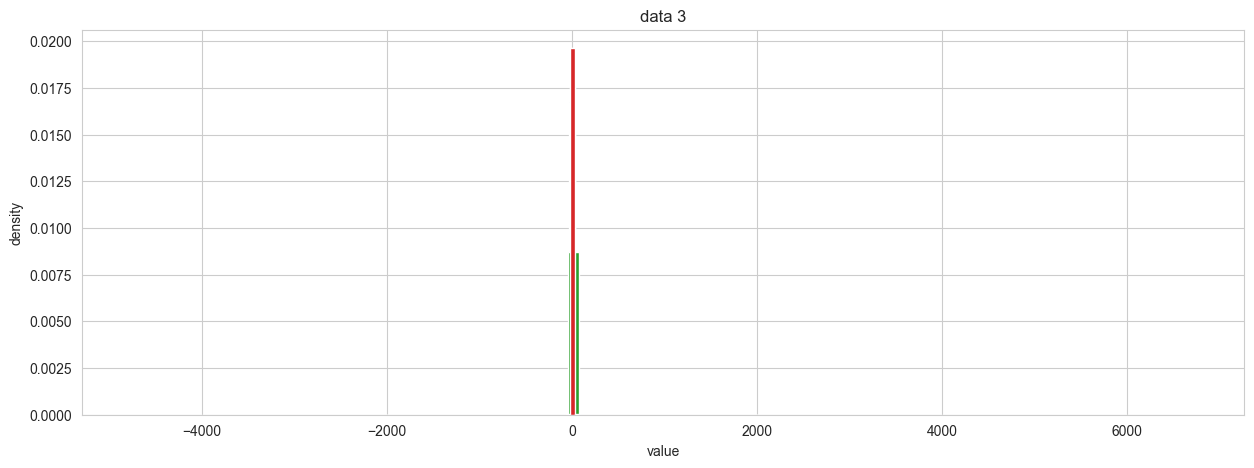

In [7]:
#plot hist with kde
plt.figure(figsize=(15, 5))
for i, data in enumerate([train_x, test_x, train_y, test_y]):
    # plt.subplot(2, 2, i+1)
    plt.hist(data, bins=100, density=True)
    plt.title(f"data {i}")
    plt.xlabel("value")
    plt.ylabel("density")

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Brent_code.config import parse_args
from Brent_code.model import EncoderDecoder
from IPython.display import clear_output

args=parse_args(layered=False)
args.debug = True
args.code_size=2**2
args.log_name = 'res/wz binning test'
args.batch_size *=10
args.lr/=10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Creating model
model = EncoderDecoder(input_dim=args.sample_dim, layers=args.layers, hidden_dim=args.hidden_units,
                       code_size=args.code_size, marginal=args.marginal)
model = model.to(device).to(torch.float)

optimizer = torch.optim.Adam(lr=args.lr, params=model.parameters())
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.lr_step, gamma=0.3)
mse_loss = nn.MSELoss()

TRAIN_BATCHES = int(args.samples_per_epoch // args.batch_size)

for epoch in range(args.epochs):

    # Train
    model.train()

    train_loss = 0.0
    train_mse_loss = 0.0

    tau_t = args.tau * np.exp(epoch/args.epochs * np.log(0.1 / args.tau))
    print('tau={:.04f}'.format(tau_t))

    x_data = torch.from_numpy(train_x).reshape(-1,1).to(torch.float)
    y_data = torch.from_numpy(train_y).reshape(-1,1).to(torch.float)
    for batch_idx in range(TRAIN_BATCHES):

        optimizer.zero_grad()

        # Source model:
        #   X = Y+N,    Y~N(0, Y_STD),  N~N(0, NOISE_STD)
        # asdasdYYYY torch.empty([args.batch_size, args.sample_dim], device=device).normal_(mean=0, std=args.y_std)
        # asdasdXXXX y + torch.empty_like(y).normal_(mean=0, std=np.sqrt(args.noise_power))
        x = x_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)
        y = y_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)

        reconstruct, bin, out, prior = model.forward(x, y, tau=tau_t)

        p_ux = out[torch.arange(out.size(0)), bin]
        p_u = prior[torch.arange(out.size(0)), bin] # it is also p_u|y for the conditional model

        dist = mse_loss(reconstruct, x)
        loss = torch.mean(torch.log(p_ux/(p_u + 1e-12))) + args.ld * dist

        train_loss += loss.item()
        train_mse_loss += dist.item()

        loss.backward()

        optimizer.step()

    scheduler.step()

    train_db = 10 * np.log10(train_mse_loss / TRAIN_BATCHES)
    train_mse_loss = train_mse_loss / TRAIN_BATCHES
    train_loss = train_loss / TRAIN_BATCHES

    # Eval:

    eval_mse_loss = 0.0
    eval_rate = 0.0

    test_samples = args.samples_per_epoch
    if epoch == args.epochs - 1 or (args.debug is False and epoch % 5 == 0):
        test_samples = args.test_samples
    test_batches = int(test_samples // args.batch_size)

    model.eval()
    x_data = torch.from_numpy(test_x).reshape(-1,1).to(torch.float)
    y_data = torch.from_numpy(test_y).reshape(-1,1).to(torch.float)
    with torch.no_grad():
        for batch_idx in range(test_batches):
            # Source model:
            #   X = Y+N,    Y~N(0, Y_STD),  N~N(0, NOISE_STD)
            # asdasdYYYY torch.empty([args.batch_size, args.sample_dim], device=device).normal_(mean=0, std=args.y_std)
            # asdasdXXXX y + torch.empty_like(y).normal_(mean=0, std=np.sqrt(args.noise_power))
            x = x_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)
            y = y_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)

            reconstruct, bin, code_probs, prior = model.forward(x, y)

            p_u = prior[torch.arange(code_probs.size(0)), bin] # also the conditional one for the second model

            dist = mse_loss(reconstruct, x)

            eval_mse_loss += dist.item()

            eval_rate += torch.mean(-torch.log2(p_u + 1e-12)).item()

    eval_db = 10*np.log10(eval_mse_loss / test_batches)
    eval_rate = eval_rate / test_batches
    print('Epoch {}: train loss={:.06f}, train_distortion={:.06f} dB, eval_distortion={:.06f} dB'
          .format(epoch, train_loss, train_db, eval_db))
    print('train_distortion={:.06f}, eval_distortion={:.06f}'
          .format(train_mse_loss, eval_mse_loss / test_batches))
    print('rate: {:.06f} bits'.format(eval_rate))

    # os.makedirs(args.log_name, exist_ok=True)
    # torch.save({
    #     'epoch': epoch,
    #     'model_state_dict': model.state_dict(),
    #     'lambda': args.ld,
    #     'config': args,
    # }, os.path.join(args.log_name, 'checkpoint.pth'))
    
    
    print("plotting...")
    min_v, max_v = test_x.min()*1.01, test_x.max()*1.01
    model.eval()
    with torch.no_grad():
        # 1D source:
        # Seeing if there is binning:
        if (args.debug and epoch % 5 == 0) or (args.debug is False and epoch == args.epochs-1):
            # clear notebook output
            clear_output()
            
            for min_v, max_v in [(min_v, max_v), np.percentile(test_x, [5, 95])]:
                fig, ax = plt.subplots(nrows=1, ncols=2)
                fig.set_size_inches(15, 5)
                
                x= torch.arange(min_v, max_v, 0.01).to(device).unsqueeze(1)
                y= torch.zeros_like(x)
                with torch.no_grad():
                    reconstruct, bin, _, _ = model.forward(x, y)
                
                ax[0].plot(x.detach().cpu().numpy(), bin.detach().cpu().numpy())
                
                bin = bin.detach().cpu().numpy()
                x = x.detach().cpu().numpy()
                unique_v = np.unique(bin)
                colors = plt.cm.viridis(np.linspace(0, 1, len(unique_v)))
                for i, val in enumerate(unique_v):
                    mask = bin == val
                    ax[0].axvline(x[mask][0], color='black', linestyle='--', linewidth=0.5)
                    temp = [x[mask][0][0], x[mask][0][0]]
                    for j in range(1, len(x[mask])):
                        if temp[1] + 0.005 < x[mask][j][0]:  # Adjusted threshold to 0.005
                            ax[0].axvspan(*temp, color=colors[i], alpha=0.3)
                            temp[0] = x[mask][j][0]
                        temp[1] = x[mask][j][0]
                    ax[0].axvspan(*temp, color=colors[i], alpha=0.3)  # Ensure the last span is added
                
                # Seeing the reconstruction points
                for i in range(args.code_size):
                    y= torch.arange(min_v, max_v, 0.01).to(device).unsqueeze(1)
                    codes = F.one_hot(torch.ones([y.shape[0]], dtype=torch.long, device=device)*i,
                                      num_classes=args.code_size).float()
                    reconstruct = model.decoder(codes, y)
                
                    ax[1].plot(y.detach().cpu().numpy(), reconstruct.detach().cpu().numpy(), label='bin={}'.format(i))
    
                ax[0].set_xlim(min_v, max_v)
                ax[1].set_xlim(min_v, max_v)
                
                plt.show()

        if epoch == args.epochs - 1 or (args.debug is False and epoch % 5 == 0):
            with open(os.path.join(args.log_name, 'results.txt'), 'a') as myfile:
                myfile.write('Epoch={}\n'.format(epoch))
                myfile.write('train_distortion={:.08f}, eval_distortion={:.08f}, rate: {:.06f} bits\n'
                             .format(train_mse_loss / TRAIN_BATCHES,
                                     eval_mse_loss / test_batches, eval_rate))




KeyboardInterrupt: 